# Probabilistic Occupancy Grid Map
---

*Narcís Palomeras - September 2022 - Universitat de Girona (all rights reserved)*

In this lab you are going to implement a 2D probabilistic occupancy grid map. Thge main idea is to combine robot poses and range measurements to create a map of free, occupied and unknown regions. We are going to assume that robot pose is known by some other method and, therefore, it is drift free.

The following elements are provided:

* `ground_truth_02.csv` file: contains the robot position at each time stamp.
* `laser_scan_02.csv` file: contains all range measurements gathered by the robot.
* `load_csv_files.py`: includes several auxiliar functions to load the `CSV` data as well as a `wrap_angle` function to normalize angles between $-\pi$ and $\pi$.


**Exercise 1:**

To familiarize yourself with the previous files do:

* load the data from `ground_truth_02.csv` and `laser_scan_02.csv` and check the format of the returned structures.
* plot the ground truth trajectory. 
* test the `bresenham` library ploting a line between $[-3, 5]$ to $[4, -2]$.

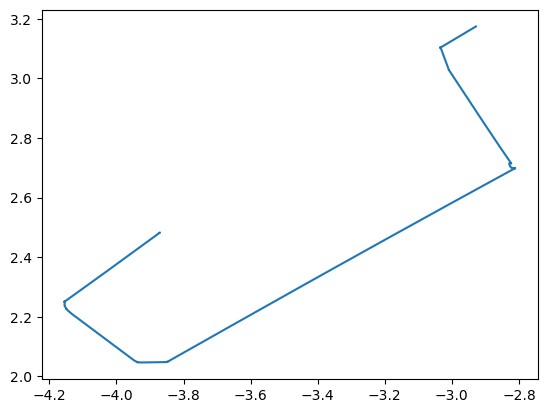

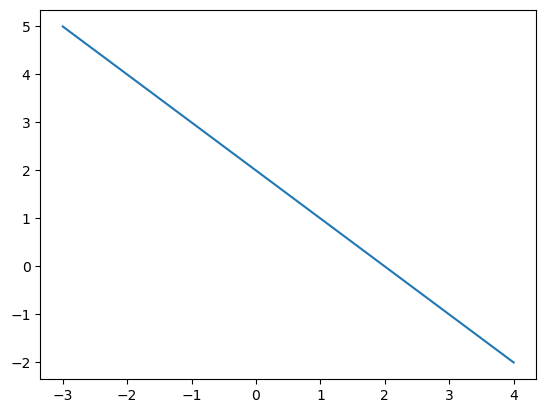

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from bresenham import bresenham # pip install bresenham if required
from load_csv_files import load_encoders, load_laser_scans, load_ground_truth, wrap_angle
from matplotlib.colors import LinearSegmentedColormap

# LOAD DATASETS
laser_scans = load_laser_scans('map1_0_laser.csv')
stamped_gt = load_ground_truth('map1_0_odom.csv')

# Extract trajectory from gt
# print(stamped_gt[:,1])
pose_x = stamped_gt[:,1]
pose_y = stamped_gt[:,2]
plt.plot(pose_x, pose_y)
plt.show()
# Plot stamped_gt trajectory
# Plot bresenham line between [-3, 5] and [4, -2] using the bresenham function from bresenham library 
# WARNING! bresenham function returns a generator, so you need to convert it to a list to use it:
# points = list(bresenham(x1, y1, x2, y2))
points = np.array(list(bresenham(-3,5,4,-2)))
plt.plot(points[:,0], points[:,1])

To create a gridmap several functions and data structures are required. We have groupped them in a single class called `GridMap`. 

**Exercise 2:**

Complete the following `GridMap` class following the comments.

In [6]:
import numpy as np
from bresenham import bresenham


class GridMap:
    """
    Probabilistic occupancy grid map. 
    """
    
    # Maximum and minimum cell loggoods (is equivalen to p_max = 0.999, p_min = 0.001)
    LMAX = 6.91 
    LMIN = -6.91

    # Initialize gridmap class
    def __init__(self, center, cell_size=0.1, map_size=10):
        self.cell_size = cell_size
        self.grid = np.zeros((int(map_size/cell_size), int(map_size/cell_size)))
        self.origin = np.array(center) - np.array([map_size, map_size])/2

    # return map
    def get_map(self):
        return self.grid

    # return origin
    def get_origin(self):
        return self.origin
    
    # Transform position wrt frame origin to cell indexes
    def __position_to_cell__(self, position):
        # Compute cell indexes from position and origin
        cell_indexes = ((position - self.origin) / self.cell_size).astype(int)

        # Check that cell indexes are within map limits
        if not (0 <= cell_indexes[0] < self.grid.shape[0] and 0 <= cell_indexes[1] < self.grid.shape[1]):
            raise ValueError("Position is outside the grid map bounds")

        return cell_indexes

    # Update cell uv with probability p
    def __update_cell__(self, uv, p):
        # Check that probability p is between 0 and 1 but not 0 or 1
        if not (0 < p < 1):
            raise ValueError("Probability p must be between 0 and 1 (exclusive)")

        # Compute inverse sensor model
        l = np.log(p / (1 - p))

        # Update cell and saturate between GridMap.LMIN and GridMap.LMAX 
        self.grid[uv[0], uv[1]] = np.clip(self.grid[uv[0], uv[1]] + l, GridMap.LMIN, GridMap.LMAX)

    # Update all cells traversed by a ray
    def add_ray(self, ray_init_position, ray_angle, ray_range, p):
        # Compute ray final position using ray start, angle and range
        ray_final_position = ray_init_position + ray_range * np.array([np.cos(ray_angle), np.sin(ray_angle)])

        # Transform intial and final position to cell indexes
        ray_init_cell = self.__position_to_cell__(ray_init_position)
        ray_final_cell = self.__position_to_cell__(ray_final_position)

        # Use Bresenham's algorithm to get traversed cells
        ray_cells = np.array(list(bresenham(ray_init_cell[0], ray_init_cell[1], ray_final_cell[0], ray_final_cell[1])))

        # Update as no occupied (probability 1-p) the cells between start and end - 1 
        # and the last cell with probability p (occupied if p is close to 1, free if p is close to 0)
        for cell in ray_cells[:-1]:
            self.__update_cell__(cell, 1-p)
        self.__update_cell__(ray_cells[-1], p)

## Dataset preparation

To create a gridmap from the robot poses and ranges it is required to have both data synchronized. 

**Exercise 3:**

Filter the `stamped_gt` data in order to have only robot positions in the time stamps in which a scan is gathered. Save the filtered poses to the `state` list. 

### pseudocode:
```
Initialize an empty list "state"
Set "i" to 0
For each "m" in "laser_scans" do
    While the first element of "stamped_gt" at index "i" is less than the first element of "m" do
        Increment "i" by 1
    End While
    Append the element at index "i" of "stamped_gt" to "state"
End For
Get the length of "state"```

1736
1736
Laser scan timestamp: 1772624435.3564277, State timestamp: 1772624435.3670325, time difference: 0.0106048583984375
Laser scan timestamp: 1772624435.3806293, State timestamp: 1772624435.3834643, time difference: 0.0028350353240966797
Laser scan timestamp: 1772624435.4497051, State timestamp: 1772624435.5003505, time difference: 0.05064535140991211
Laser scan timestamp: 1772624435.558889, State timestamp: 1772624435.561056, time difference: 0.0021669864654541016
Laser scan timestamp: 1772624435.6186724, State timestamp: 1772624436.1848912, time difference: 0.5662188529968262
Laser scan timestamp: 1772624436.1852872, State timestamp: 1772624436.1950204, time difference: 0.009733200073242188
Laser scan timestamp: 1772624436.1952543, State timestamp: 1772624436.199615, time difference: 0.004360675811767578
Laser scan timestamp: 1772624436.2001128, State timestamp: 1772624436.2034936, time difference: 0.0033807754516601562
Laser scan timestamp: 1772624436.2036047, State timestamp: 

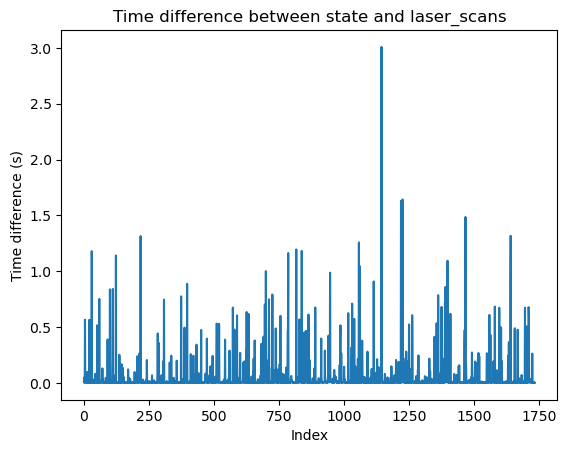

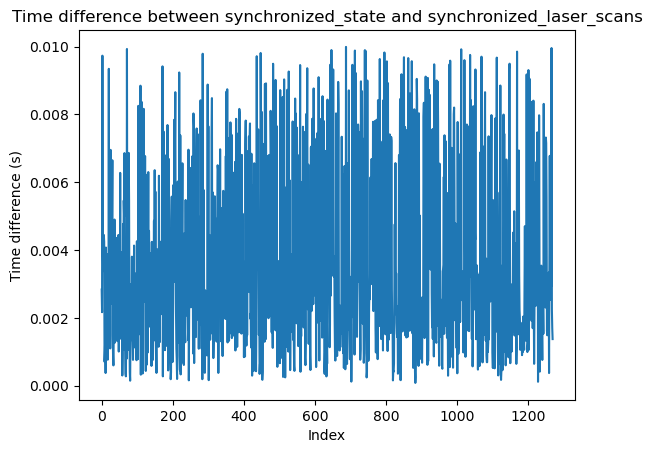

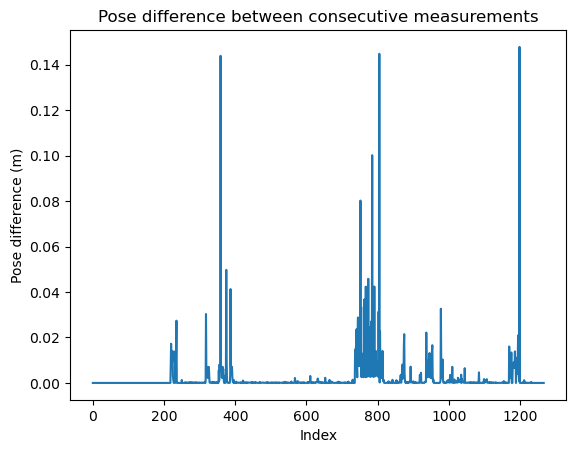

In [7]:
state = []
# Filter `stamped_gt` data to have the same dimension of `laser_scans` and be synchronized with it
i = 0
for m in laser_scans:
    while stamped_gt[i][0] < m[0]:
        i = i + 1
        # print(i)
    state.append(stamped_gt[i])
print(len(state))
print(len(laser_scans))

# print time stamps of laser_scans and state to check they are synchronized
for i in range(10):
    print(f"Laser scan timestamp: {laser_scans[i][0]}, State timestamp: {state[i][0]}, time difference: {state[i][0] - laser_scans[i][0]}")

timediff = [state[i][0] - laser_scans[i][0] for i in range(len(laser_scans))]
# plot time difference between state and laser_scans
plt.plot(timediff)
plt.title("Time difference between state and laser_scans")
plt.xlabel("Index")
plt.ylabel("Time difference (s)")
plt.show()

# Improve time synchronization by only keeping the laser scans and states that are within a certain time threshold (e.g., 0.1s)
time_threshold = 0.01
synchronized_laser_scans = []
synchronized_state = []
for i in range(len(laser_scans)):
    if abs(state[i][0] - laser_scans[i][0]) < time_threshold:
        synchronized_laser_scans.append(laser_scans[i])
        synchronized_state.append(state[i])

timediff = [synchronized_state[i][0] - synchronized_laser_scans[i][0] for i in range(len(synchronized_laser_scans))]
# plot time difference between synchronized_state and synchronized_laser_scans
plt.plot(timediff)
plt.title("Time difference between synchronized_state and synchronized_laser_scans")
plt.xlabel("Index")
plt.ylabel("Time difference (s)")
plt.show()

# compute difference of pose between previous measurement and current measurement to detect jumps in the trajectory
pose_diff = []
for i in range(1, len(synchronized_state)):
    pose_diff.append(np.linalg.norm(synchronized_state[i][1:3] - synchronized_state[i-1][1:3]))
# plot pose difference
plt.plot(pose_diff)
plt.title("Pose difference between consecutive measurements")
plt.xlabel("Index")
plt.ylabel("Pose difference (m)")
plt.show()


## Building the Probabilistic Grid Map

Now that all data is loaded and synchronized and that the `GridMap` class is ready is time to build the probabilistic grid map.

**Exercise 4:**

For each scan in the `laser_scans` list add each one of its rays in the gridmap using the `add_ray` method. You need to provide the robot position, where it gathered this beam, and the beam orientation. Be aware that the beam orientation is the composition of the robot orientation and the beam *theta*.

> Note 1: use only ranges that its value is between `min_range` and `max_range`

> Note 2: This process is quite large. Start testing with only few scans and, when it works, try with the full dataset.

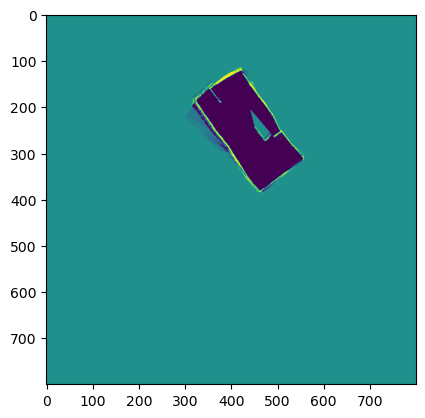

In [ ]:
# Initialize data
min_range = 0.15000000596046448
max_range = 16.0
cell_size = 0.01
map_size = 8
gridmap = GridMap(np.array([-2, 2]), cell_size, map_size)

for scan, state in zip(synchronized_laser_scans, synchronized_state):
    scan_range_list = scan[1] # list of ranges for each ray
    scan_angle_list = scan[2] # list of angles for each ray (relative to robot orientation)
    for scan_range, scan_angle in zip(scan_range_list, scan_angle_list):
        if min_range < scan_range < max_range: # only consider valid ranges
            LIDAR_OFFSET = np.pi / 2
            ray_angle = scan_angle + state[3] + LIDAR_OFFSET # add robot orientation to ray angle to get ray angle in world frame
            gridmap.add_ray(state[1:3], ray_angle, scan_range, p=0.7) # add ray to gridmap with p=0.7 (occupied)


fig, ax = plt.subplots()
cax = ax.imshow(gridmap.get_map(), cmap='viridis', origin='upper')
plt.show()

# save image
plt.imsave('gridmap.png', gridmap.get_map(), cmap='viridis', origin='upper')
